# 09e. Audit GAVD checkpoint health and reflection geometry

This notebook is intentionally separate from optimization. It reloads each saved checkpoint, measures
even/odd representation health, and evaluates the layerwise swap contract on both online and EMA
encoders. A passing local verdict means only that the implementation is ready for a non-clinical,
subject-disjoint pretraining study such as AMASS.


In [1]:
from pathlib import Path
import json, math, os, sys

def find_notebook_root(start=None):
    start = Path(start or Path.cwd()).expanduser().resolve()
    relative_path = Path("experiments") / "sjepa" / "gavd6"
    candidates = []
    override = os.getenv("GAIT_PARITY_PROJECT_DIR")
    if override:
        candidates.append(Path(override).expanduser().resolve())
    for base in (start, *start.parents):
        candidates.extend((base, base / relative_path))
    for candidate in dict.fromkeys(candidates):
        if ((candidate / "gait_parity_jepa.py").is_file()
                and (candidate / "notebooks" / "nb_09a_equivariant_encoder_contract.ipynb").is_file()):
            return candidate
    searched = "\n - ".join(str(path) for path in dict.fromkeys(candidates))
    raise FileNotFoundError(
        "Could not locate experiments/sjepa/gavd6. "
        "Set GAIT_PARITY_PROJECT_DIR to that directory.\n"
        f"Searched:\n - {searched}"
    )

PROJECT_DIR = find_notebook_root()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from gait_parity_jepa import *

MODE = os.getenv("GAIT_PARITY_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAIT_PARITY_MODE must be smoke or real")
PROFILE_NAME = "smoke" if MODE == "smoke" else os.getenv("GAIT_PARITY_PROFILE", "cpu").strip().lower()
if PROFILE_NAME not in PROFILES or (MODE == "real" and PROFILE_NAME == "smoke"):
    raise ValueError("Real runs require GAIT_PARITY_PROFILE=cpu or gpu")
CONFIG = PROFILES[PROFILE_NAME]
MATCHING_REGIME = os.getenv("GAIT_PARITY_MATCHING", "exposure").strip().lower()
if MATCHING_REGIME not in {"exposure", "compute"}:
    raise ValueError("GAIT_PARITY_MATCHING must be exposure or compute")
RUN_ID = os.getenv("GAIT_PARITY_RUN_ID", "smoke")
if MODE == "real" and RUN_ID == "smoke":
    raise ValueError("Set a versioned GAIT_PARITY_RUN_ID for a real run")
SEEDS = [int(value) for value in os.getenv(
    "GAIT_PARITY_SEEDS", "7" if PROFILE_NAME in {"cpu", "smoke"} else "7,19,31"
).split(",")]
OUT_DIR = PROJECT_DIR / "work" / "artifacts" / "gait_parity" / MODE / RUN_ID / MATCHING_REGIME
OUT_DIR.mkdir(parents=True, exist_ok=True)

if MODE == "smoke":
    RECORDS = synthetic_records(frames=48)
    POSE_DIR = None
else:
    POSE_DIR = resolve_pose_dir(PROJECT_DIR)
    RECORDS = load_gavd_records(POSE_DIR)
WINDOWS, VALID_PATCH, WINDOW_TABLE = build_windows(RECORDS, CONFIG)
MANIFEST = cohort_manifest(RECORDS, WINDOW_TABLE, CONFIG, MODE)

print("scope            :", MANIFEST["scope"])
print("mode/profile     :", MODE, "/", PROFILE_NAME)
print("matching regime  :", MATCHING_REGIME)
print("run ID           :", RUN_ID)
print("device default   :", os.getenv("GAIT_PARITY_DEVICE", "cpu"))
print("records/windows  :", len(RECORDS), "/", len(WINDOWS))
print("source videos    :", MANIFEST["source_video_count"])
print("output           :", OUT_DIR)


scope            : local GAVD feasibility; transductive representation/geometry evidence only
mode/profile     : smoke / smoke
matching regime  : exposure
run ID           : smoke
device default   : cpu
records/windows  : 12 / 24
source videos    : 6
output           : /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/gait_parity/smoke/smoke/exposure


## 1. Load the frozen contract and completed training manifest


In [2]:
contract_path = OUT_DIR / "training_contract.json"
training_path = OUT_DIR / "training_manifest.json"
if not contract_path.exists() or not training_path.exists():
    raise FileNotFoundError("Run nb_09c and nb_09d with this exact run ID/regime first")
CONTRACT = json.loads(contract_path.read_text())
TRAINING = json.loads(training_path.read_text())
GATES = CONTRACT["health_gates"]
assert CONTRACT["cohort_manifest"]["cohort_sha256"] == MANIFEST["cohort_sha256"]
assert CONTRACT["cohort_manifest"]["window_sha256"] == MANIFEST["window_sha256"]
print("checkpoints:", len(TRAINING["runs"]))


checkpoints: 3


## 2. Reload, audit health, and test commutation

The standard orbit shell commutes because the same ordinary encoder processes both members independently;
that fact is not called a paired equivariant architecture because it has no cross-branch interaction.
The paired-unconstrained control must produce a nonzero residual, demonstrating that the test can fail.
Only the reflection-equivariant encoder is required to combine cross-branch interaction with a passing
online and EMA layerwise contract.


In [3]:
health_rows, geometry_rows = [], []
contract_size = min(8, len(WINDOWS))
contract_batch = WINDOWS[:contract_size]
contract_valid = VALID_PATCH[:contract_size]
contract_target_mask = sample_mask(
    contract_valid, CONFIG.mask_fraction, torch.Generator().manual_seed(909)
)
contract_keep_mask = ~contract_target_mask
AUDIT_DEVICE = device_from_environment()
precision_cases = [("float32", False)]
if AUDIT_DEVICE.type == "cuda" and CONFIG.amp:
    precision_cases.append(("float16_autocast", True))
for run in TRAINING["runs"]:
    model, projector, metadata = load_checkpoint(run["checkpoint"])
    even, odd = collect_parity_features(model.target_encoder, WINDOWS, batch_size=CONFIG.batch_size)
    even_metrics, odd_metrics = representation_metrics(even), representation_metrics(odd)
    ratio = odd_metrics["energy"] / max(even_metrics["energy"], 1e-12)
    health_pass = bool(
        even_metrics["feature_variance"] >= GATES["minimum_feature_variance"]
        and odd_metrics["feature_variance"] >= GATES["minimum_feature_variance"]
        and even_metrics["effective_rank"] >= GATES["minimum_effective_rank"]
        and odd_metrics["effective_rank"] >= GATES["minimum_effective_rank"]
        and even_metrics["mean_pairwise_cosine"] <= GATES["maximum_mean_pairwise_cosine"]
        and odd_metrics["mean_pairwise_cosine"] <= GATES["maximum_mean_pairwise_cosine"]
        and GATES["minimum_odd_to_even_energy_ratio"] <= ratio <= GATES["maximum_odd_to_even_energy_ratio"]
    )
    health_rows.append({
        "seed": metadata["seed"], "variant": metadata["variant"],
        **{f"even_{k}": v for k, v in even_metrics.items()},
        **{f"odd_{k}": v for k, v in odd_metrics.items()},
        "odd_to_even_energy_ratio": ratio, "health_pass": health_pass,
    })
    for encoder_name, encoder in [("online", model.encoder), ("ema_teacher", model.target_encoder)]:
        encoder = encoder.to(AUDIT_DEVICE)
        for mode_name, train_mode in [("eval", False), ("train", True)]:
            for mask_name, keep_mask in [("unmasked", None), ("masked", contract_keep_mask)]:
                for precision_name, use_amp in precision_cases:
                    report = commutation_report(
                        encoder, contract_batch, keep_mask=keep_mask, train_mode=train_mode,
                        device=AUDIT_DEVICE, mixed_precision=use_amp,
                    )
                    for row in report.to_dict(orient="records"):
                        geometry_rows.append({
                            "seed": metadata["seed"], "variant": metadata["variant"],
                            "encoder": encoder_name, "mode": mode_name, "mask": mask_name,
                            "precision": precision_name, **row,
                        })

health = pd.DataFrame(health_rows)
geometry = pd.DataFrame(geometry_rows)
display(health)
display(geometry.groupby(["seed", "variant", "encoder", "mode", "mask", "precision"]).max(numeric_only=True))


,seed,variant,even_energy,even_feature_variance,even_effective_rank,even_mean_pairwise_cosine,odd_energy,odd_feature_variance,odd_effective_rank,odd_mean_pairwise_cosine,odd_to_even_energy_ratio,health_pass
0,7,standard,0.339161,0.010102,1.829850,0.969942,0.008210,0.004895,1.719419,0.388561,0.024206,True
1,7,paired_unconstrained,0.304889,0.017360,1.600753,0.942703,0.238400,0.011086,1.711944,0.956546,0.781924,True
2,7,reflection_equivariant,0.531680,0.014835,1.657867,0.972193,0.011298,0.007571,1.587158,0.321173,0.021249,True


layer  \
seed variant                encoder     mode  mask     precision          
7    paired_unconstrained   ema_teacher eval  masked   float32        2   
                                              unmasked float32        2   
                                        train masked   float32        2   
                                              unmasked float32        2   
                            online      eval  masked   float32        2   
                                              unmasked float32        2   
                                        train masked   float32        2   
                                              unmasked float32        2   
     reflection_equivariant ema_teacher eval  masked   float32        2   
                                              unmasked float32        2   
                                        train masked   float32        2   
                                              unmasked float32        2   
                            online      eval  masked   float32        2   
                                              unmasked float32        2   
                                        train masked   float32        2   
                                              unmasked float32        2   
     standard               ema_teacher eval  masked   float32        2   
                                              unmasked float32        2   
                                        train masked   float32        2   
                                              unmasked float32        2   
                            online      eval  masked   float32        2   
                                              unmasked float32        2   
                                        train masked   float32        2   
                                              unmasked float32        2   

                                                                   max_abs  \
seed variant                encoder     mode  mask     precision             
7    paired_unconstrained   ema_teacher eval  masked   float32    3.896409   
                                              unmasked float32    3.864462   
                                        train masked   float32    3.896409   
                                              unmasked float32    3.864461   
                            online      eval  masked   float32    3.751288   
                                              unmasked float32    3.670967   
                                        train masked   float32    3.751287   
                                              unmasked float32    3.670967   
     reflection_equivariant ema_teacher eval  masked   float32    0.000000   
                                              unmasked float32    0.000000   
                                        train masked   float32    0.000000   
                                              unmasked float32    0.000000   
                            online      eval  masked   float32    0.000000   
                                              unmasked float32    0.000000   
                                        train masked   float32    0.000000   
                                              unmasked float32    0.000000   
     standard               ema_teacher eval  masked   float32    0.000000   
                                              unmasked float32    0.000000   
                                        train masked   float32    0.000000   
                                              unmasked float32    0.000000   
                            online      eval  masked   float32    0.000000   
                                              unmasked float32    0.000000   
                                        train masked   float32    0.000000   
                                              unmasked float32    0.000000   

                                                                   max_rel  
seed vari

## 3. Apply the predeclared local-feasibility gates


In [4]:
maximums = geometry.groupby(["seed", "variant", "encoder", "mode", "mask", "precision"], as_index=False).max(numeric_only=True)
eq_geometry = maximums[maximums.variant == "reflection_equivariant"]
free_geometry = maximums[maximums.variant == "paired_unconstrained"]
geometry_pass = bool((eq_geometry.max_abs <= GATES["equivariance_float32_atol"]).all())
control_pass = bool((free_geometry.max_abs >= GATES["unconstrained_control_minimum_residual"]).all())
health_pass = bool(health.health_pass.all())
checkpoints_complete = len(health) == len(SEEDS) * len(VARIANTS)
verdict = {
    "checkpoints_complete": checkpoints_complete,
    "all_representation_health_gates_pass": health_pass,
    "equivariant_online_and_teacher_geometry_pass": geometry_pass,
    "unconstrained_control_demonstrates_test_power": control_pass,
    "local_feasibility_pass": bool(checkpoints_complete and health_pass and geometry_pass and control_pass),
    "claim_ceiling": MANIFEST["scope"],
}
print(json.dumps(verdict, indent=2))


{
  "checkpoints_complete": true,
  "all_representation_health_gates_pass": true,
  "equivariant_online_and_teacher_geometry_pass": true,
  "unconstrained_control_demonstrates_test_power": true,
  "local_feasibility_pass": true,
  "claim_ceiling": "local GAVD feasibility; transductive representation/geometry evidence only"
}


## 4. Persist audit tables and diagnostic figure

No model is ranked by downstream accuracy here. GAVD can tell us whether the loop is technically viable;
it cannot decide whether encoder-wide parity beats output repair on held-out clinical force.


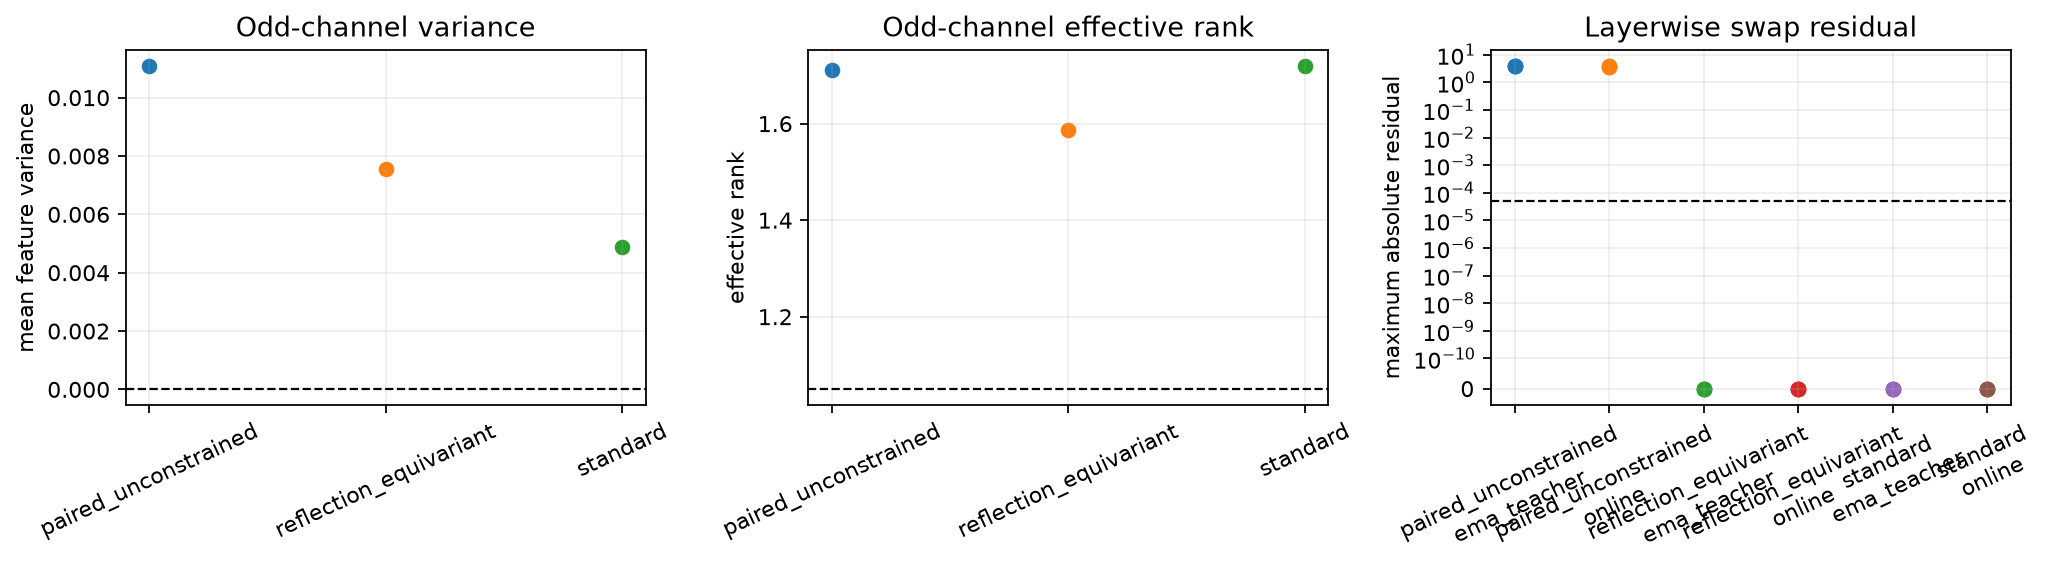

Wrote /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/gait_parity/smoke/smoke/exposure/checkpoint_audit.json


In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

health.to_csv(OUT_DIR / "checkpoint_health.csv", index=False)
geometry.to_csv(OUT_DIR / "checkpoint_geometry.csv", index=False)
figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for variant, frame in health.groupby("variant"):
    axes[0].scatter([variant] * len(frame), frame.odd_feature_variance, label=variant)
    axes[1].scatter([variant] * len(frame), frame.odd_effective_rank)
for (variant, encoder), frame in maximums.groupby(["variant", "encoder"]):
    axes[2].scatter([f"{variant}\n{encoder}"] * len(frame), frame.max_abs)
axes[0].axhline(GATES["minimum_feature_variance"], color="black", ls="--", lw=1)
axes[0].set(title="Odd-channel variance", ylabel="mean feature variance")
axes[1].axhline(GATES["minimum_effective_rank"], color="black", ls="--", lw=1)
axes[1].set(title="Odd-channel effective rank", ylabel="effective rank")
axes[2].set_yscale("symlog", linthresh=1e-10)
axes[2].axhline(GATES["equivariance_float32_atol"], color="black", ls="--", lw=1)
axes[2].set(title="Layerwise swap residual", ylabel="maximum absolute residual")
for axis in axes:
    axis.tick_params(axis="x", rotation=25)
    axis.grid(alpha=0.2)
figure.tight_layout()
figure_path = OUT_DIR / "checkpoint_audit.png"
figure.savefig(figure_path, dpi=160, bbox_inches="tight")
from IPython.display import Image, display
display(Image(filename=str(figure_path)))
plt.close(figure)

audit = {
    "notebook": "nb_09e_gavd_matched_jepa_audit",
    "verdict": verdict,
    "health": health.to_dict(orient="records"),
    "geometry": geometry.to_dict(orient="records"),
    "figure": str(figure_path),
}
write_json(OUT_DIR / "checkpoint_audit.json", audit)
print("Wrote", OUT_DIR / "checkpoint_audit.json")
